# Depression Model


## Import Library

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

## Load Data

In [25]:
df = pd.read_csv('data/Depression.csv')
print(df.head())

  1. Age 2. Gender                                      3. University  \
0  18-22    Female           Independent University, Bangladesh (IUB)   
1  18-22      Male           Independent University, Bangladesh (IUB)   
2  18-22      Male  American International University Bangladesh (...   
3  18-22      Male  American International University Bangladesh (...   
4  18-22      Male                       North South University (NSU)   

                                  4. Department           5. Academic Year  \
0  Engineering - CS / CSE / CSC / Similar to CS  Second Year or Equivalent   
1  Engineering - CS / CSE / CSC / Similar to CS   Third Year or Equivalent   
2  Engineering - CS / CSE / CSC / Similar to CS   Third Year or Equivalent   
3  Engineering - CS / CSE / CSC / Similar to CS   Third Year or Equivalent   
4  Engineering - CS / CSE / CSC / Similar to CS  Second Year or Equivalent   

  6. Current CGPA  \
0     2.50 - 2.99   
1     3.00 - 3.39   
2     3.00 - 3.39   
3     3.

## Preprocessing Data

In [29]:
# Pemisahan fitur dan target
X = df.drop(['Depression Value', 'Depression Label'], axis=1)
y = df['Depression Label']

# Mengelompokkan fitur berdasarkan tipe data
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Kolom fitur numerik:", list(numerical_features))
print("Kolom fitur kategorikal:", list(categorical_features))

Kolom fitur numerik: ['1. In a semester, how often have you had little interest or pleasure in doing things?', '2. In a semester, how often have you been feeling down, depressed or hopeless?', '3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much? ', '4. In a semester, how often have you been feeling tired or having little energy? ', '5. In a semester, how often have you had poor appetite or overeating? ', '6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down? ', '7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television? ', "8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless? ", '9. In a semester, how often have you had thoughts that you would be better off dead, or of hurtin

In [30]:
# Membuat preprocessor untuk fitur numerik dan kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ], remainder='passthrough')

In [31]:
# Pipeline untuk preprocessing dan klasifikasi
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs'))
])

In [32]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Jumlah Data Latih (Train):", X_train.shape[0])
print("Jumlah Data Uji (Test):", X_test.shape[0])

Jumlah Data Latih (Train): 1622
Jumlah Data Uji (Test): 406


## Hyperparameter Tuning

In [33]:
# grid search untuk hyperparameter tuning
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'] # l2 adalah standar untuk solver lbfgs
}

grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

print("Memulai Hyperparameter Tuning...")
grid_search.fit(X_train, y_train)

print("Parameter Terbaik:", grid_search.best_params_)

Memulai Hyperparameter Tuning...
Parameter Terbaik: {'classifier__C': 100, 'classifier__penalty': 'l2'}


## Evaluasi Model

In [34]:
# Mengambil model terbaik dari grid search
best_model = grid_search.best_estimator_

# Evaluasi pada data test
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Akurasi pada data test:", f"{accuracy * 100:.2f}%", "\n")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Akurasi pada data test: 99.01% 


Classification Report:
                               precision    recall  f1-score   support

             Mild Depression       0.99      1.00      0.99        83
          Minimal Depression       0.94      0.89      0.92        19
         Moderate Depression       1.00      0.99      0.99        92
Moderately Severe Depression       1.00      1.00      1.00       102
               No Depression       0.80      0.89      0.84         9
           Severe Depression       1.00      1.00      1.00       101

                    accuracy                           0.99       406
                   macro avg       0.96      0.96      0.96       406
                weighted avg       0.99      0.99      0.99       406



## Visualisasi Confusion Matrix

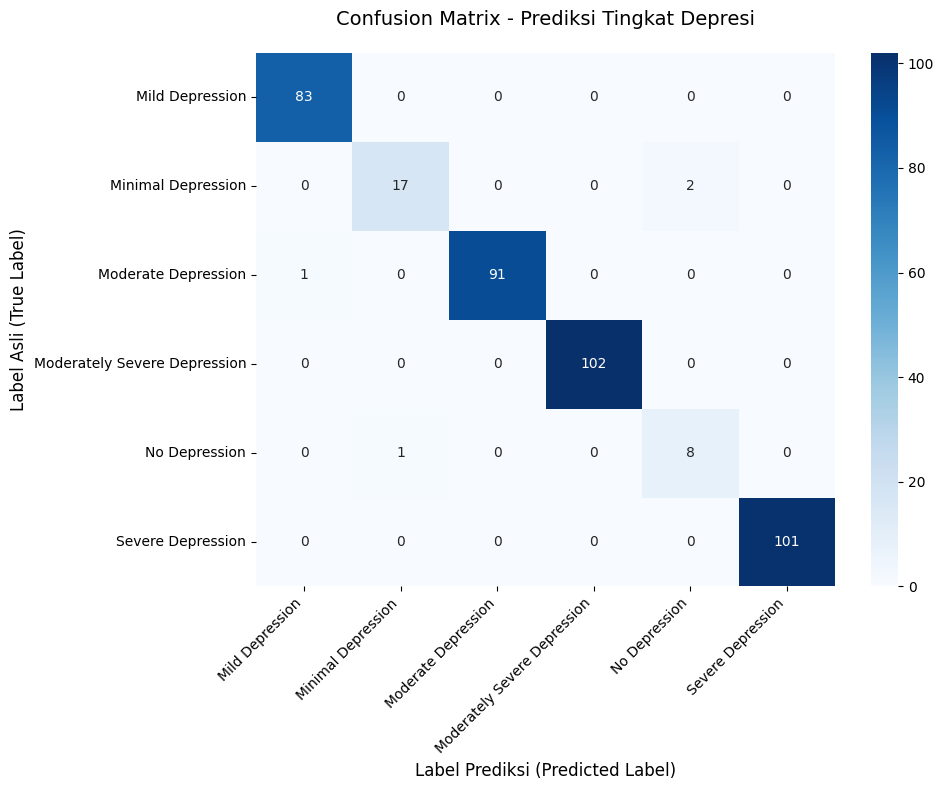

In [35]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title('Confusion Matrix - Prediksi Tingkat Depresi', pad=20, fontsize=14)
plt.ylabel('Label Asli (True Label)', fontsize=12)
plt.xlabel('Label Prediksi (Predicted Label)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Saved Model

In [36]:
# saved model
import joblib
import os

path = os.path.join('saved_models', 'depression_model.pkl')
joblib.dump(best_model, path)
print("Model telah disimpan sebagai 'depression_model.pkl'")

Model telah disimpan sebagai 'depression_model.pkl'
